<a href="https://colab.research.google.com/github/Gowrav06/Data-Science/blob/main/Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

In [48]:
# Load data (sheet 1 has the data)
df = pd.read_excel('glass.xlsx', sheet_name=1, header=0)

print("Dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:\n", df.head())
print("\nMissing values:\n", df.isnull().sum())
print("\nTarget distribution:\n", df['Type'].value_counts().sort_index())
print("\nDataset description:\n", df.describe())

Dataset shape: (214, 10)

Columns: ['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type']

First 5 rows:
         RI     Na    Mg    Al     Si     K    Ca   Ba   Fe  Type
0  1.52101  13.64  4.49  1.10  71.78  0.06  8.75  0.0  0.0     1
1  1.51761  13.89  3.60  1.36  72.73  0.48  7.83  0.0  0.0     1
2  1.51618  13.53  3.55  1.54  72.99  0.39  7.78  0.0  0.0     1
3  1.51766  13.21  3.69  1.29  72.61  0.57  8.22  0.0  0.0     1
4  1.51742  13.27  3.62  1.24  73.08  0.55  8.07  0.0  0.0     1

Missing values:
 RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

Target distribution:
 Type
1    70
2    76
3    17
5    13
6     9
7    29
Name: count, dtype: int64

Dataset description:
                RI          Na          Mg          Al          Si           K  \
count  214.000000  214.000000  214.000000  214.000000  214.000000  214.000000   
mean     1.518365   13.407850    2.684533    1.444907   72.650935    0.497056  

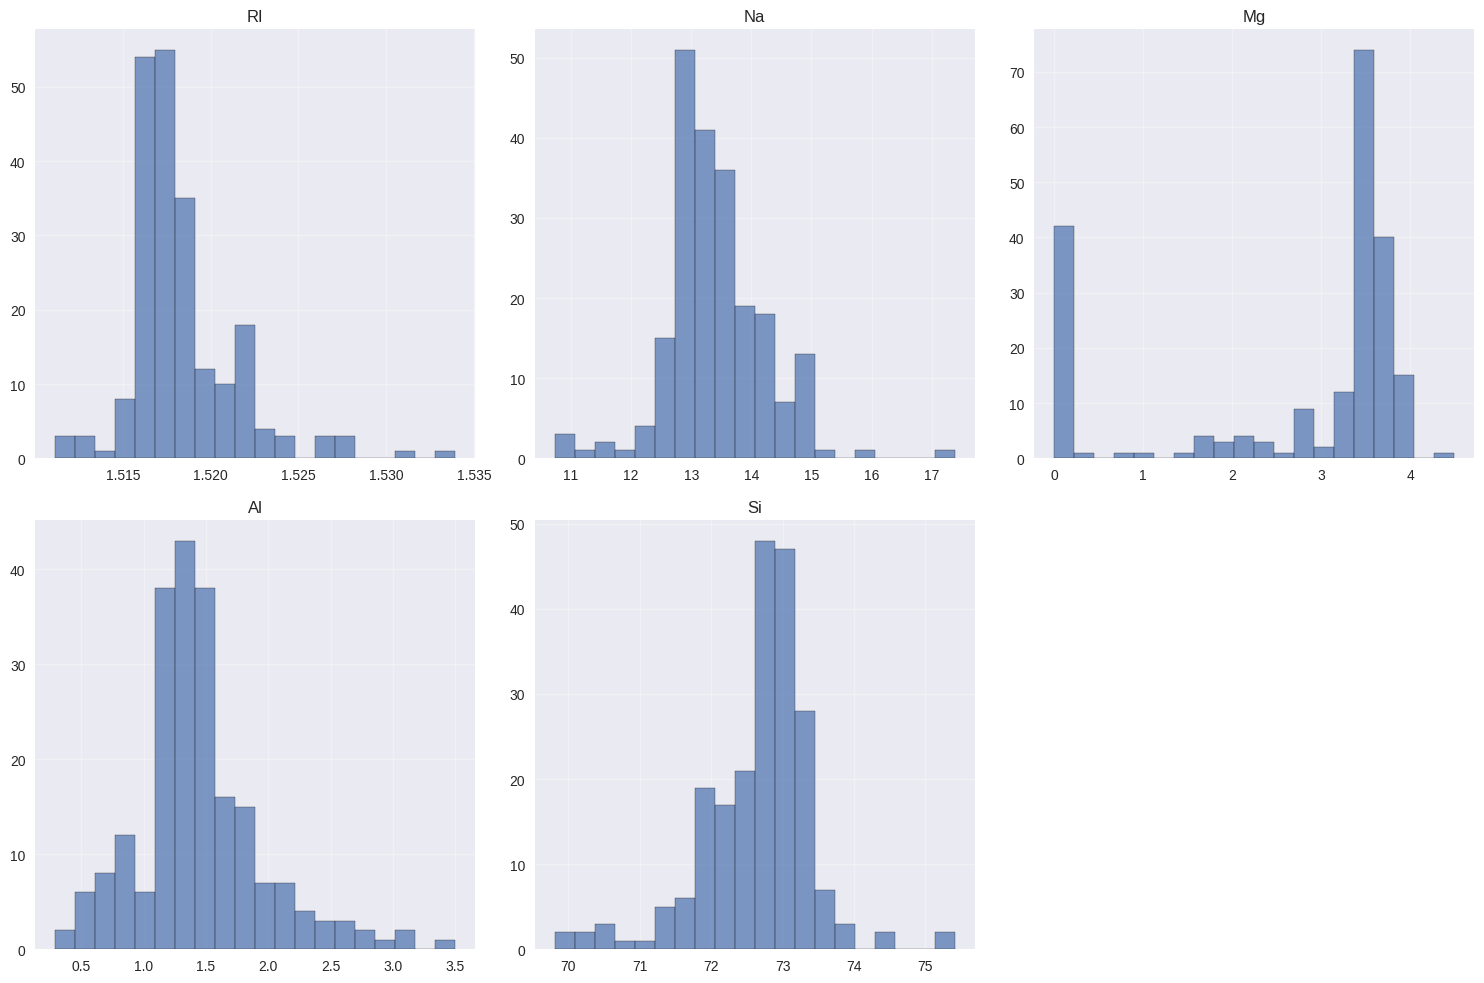

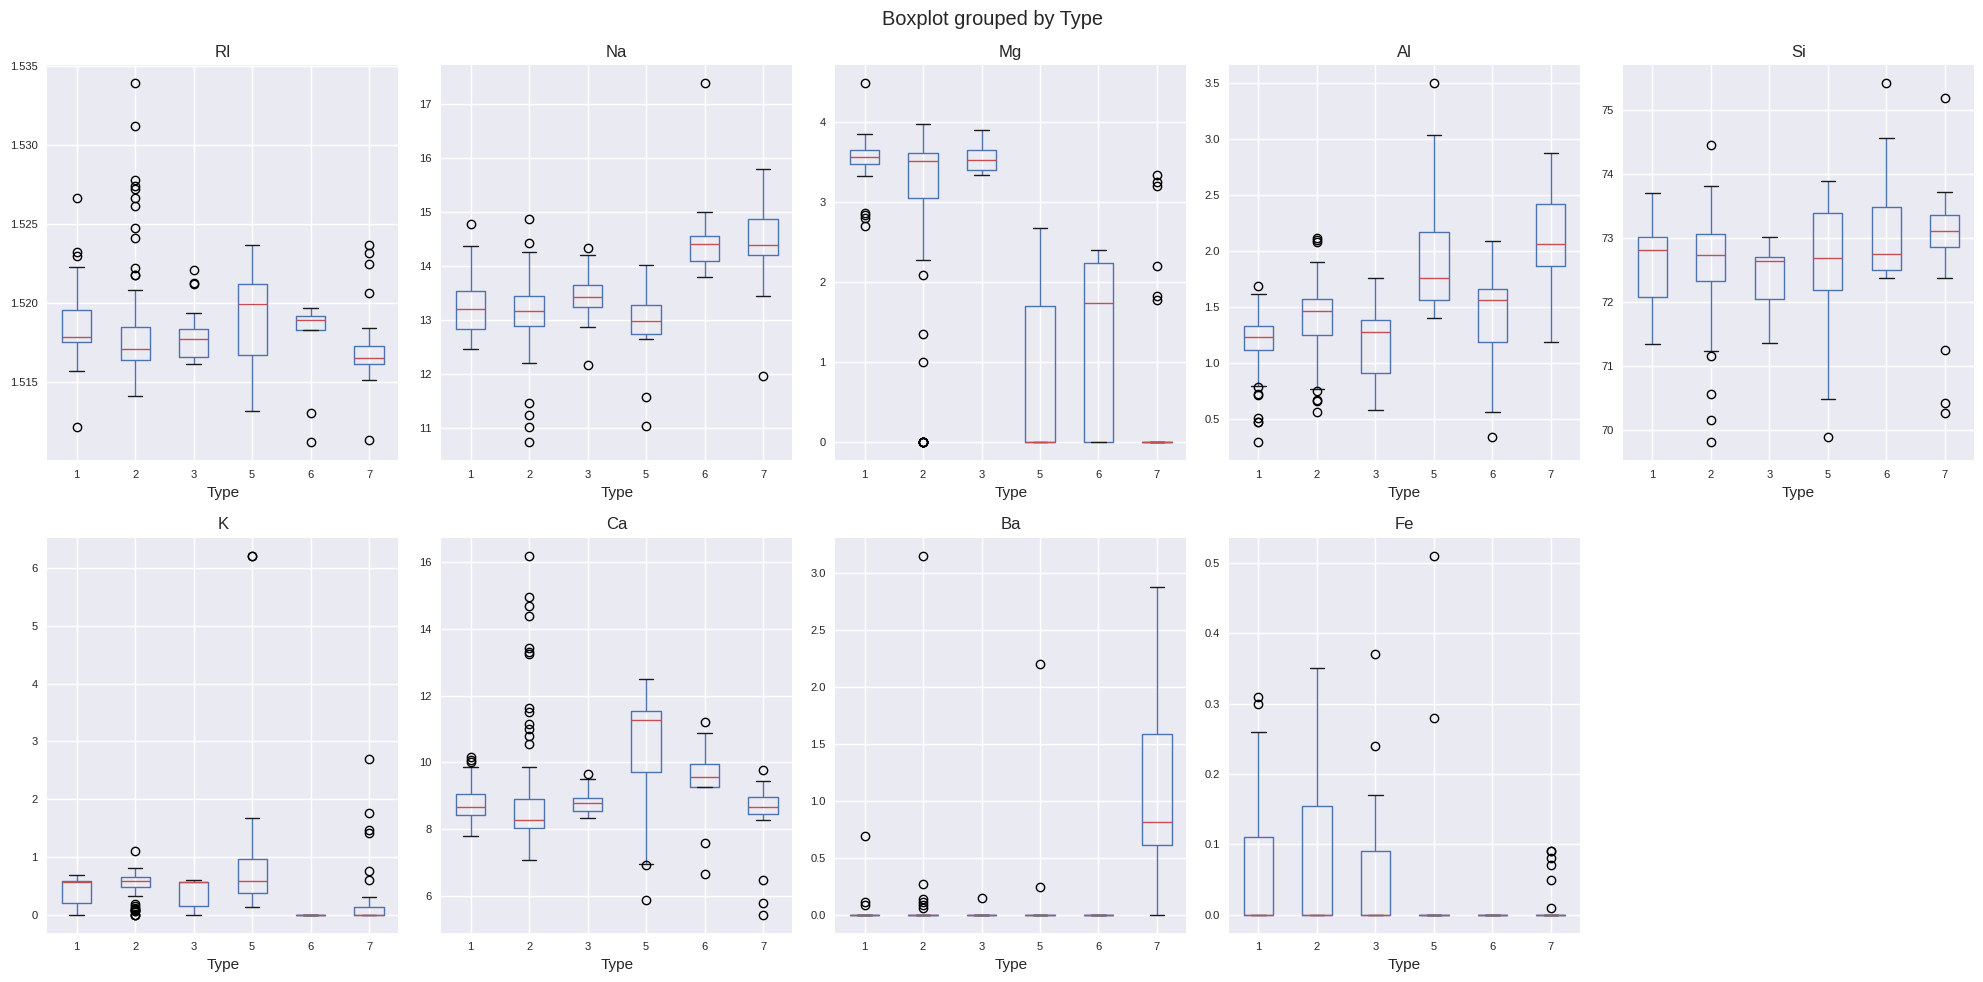

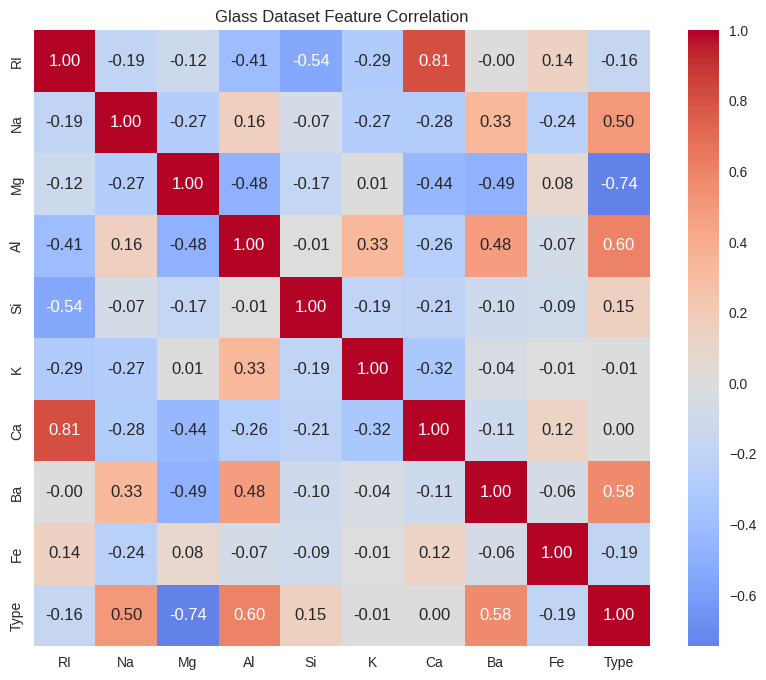

<Figure size 1307.88x1250 with 0 Axes>

In [59]:
import os

# Create output directory if missing
os.makedirs('output', exist_ok=True)

# Set style
plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(2, 3, figsize=(15,10))
axes = axes.ravel()

# Histograms using ax.hist
feature_cols = df.columns[:-1].tolist()
for idx, col in enumerate(feature_cols):
    if idx < 6:
        axes[idx].hist(df[col], bins=20, alpha=0.7, edgecolor='black')
        axes[idx].set_title(col)
        axes[idx].grid(True, alpha=0.3)

axes[5].set_visible(False)
plt.tight_layout()
plt.savefig('output/glass_histograms_fixed.png', dpi=300, bbox_inches='tight')
plt.show()

# Boxplots
fig, axes = plt.subplots(2, 5, figsize=(20,10))
axes = axes.ravel()
for idx, col in enumerate(feature_cols):
    df.boxplot(column=col, by='Type', ax=axes[idx], fontsize=8)
    axes[idx].set_title(col)

for idx in range(len(feature_cols), 10):
    axes[idx].set_visible(False)
plt.tight_layout()
plt.savefig('output/glass_boxplots_fixed.png', dpi=300, bbox_inches='tight')
plt.show()

# Correlation
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0, square=True, fmt='.2f')
plt.title('Glass Dataset Feature Correlation')
plt.savefig('output/glass_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

# Pairplot (saves automatically)
sns.pairplot(df[['RI','Na','Mg','Al','Si','Type']], hue='Type', diag_kind='hist')
plt.savefig('output/glass_pairplot.png', dpi=300, bbox_inches='tight')
plt.clf()  # Clear to avoid display overlap

In [60]:
# No missing values, all numeric already

# Features and target
X = df.drop('Type', axis=1)
y = df['Type']

print("Original class distribution:", Counter(y))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Handle imbalance with SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print("After SMOTE:", Counter(y_train_res))

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

print("Preprocessing complete.")

Original class distribution: Counter({2: 76, 1: 70, 7: 29, 3: 17, 5: 13, 6: 9})
After SMOTE: Counter({7: 61, 1: 61, 2: 61, 3: 61, 6: 61, 5: 61})
Preprocessing complete.


Random Forest Results:
Accuracy: 0.7674418604651163

Classification Report:
               precision    recall  f1-score   support

           1       0.77      0.71      0.74        14
           2       0.79      0.73      0.76        15
           3       0.40      0.67      0.50         3
           5       1.00      1.00      1.00         3
           6       0.67      1.00      0.80         2
           7       1.00      0.83      0.91         6

    accuracy                           0.77        43
   macro avg       0.77      0.82      0.78        43
weighted avg       0.79      0.77      0.77        43



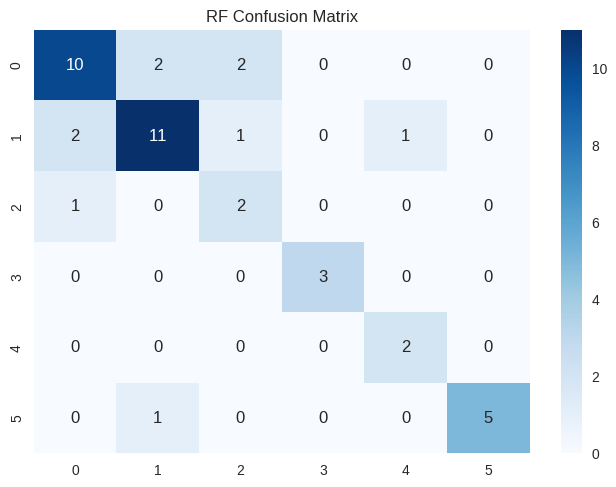

In [61]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train_res)

# Predict
y_pred_rf = rf.predict(X_test_scaled)

# Metrics
print("Random Forest Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title('RF Confusion Matrix')
plt.savefig('output/rf_cm.png')
plt.show()

In [62]:
# Bagging (DT base)
bag = BaggingClassifier(n_estimators=100, random_state=42, n_jobs=-1)
bag.fit(X_train_scaled, y_train_res)
y_pred_bag = bag.predict(X_test_scaled)

print("Bagging Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_bag))
print("\nClassification Report:\n", classification_report(y_test, y_pred_bag))

# Boosting: AdaBoost
from sklearn.ensemble import AdaBoostClassifier
boost = AdaBoostClassifier(n_estimators=100, random_state=42)
boost.fit(X_train_scaled, y_train_res)
y_pred_boost = boost.predict(X_test_scaled)

print("Boosting (AdaBoost) Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_boost))
print("\nClassification Report:\n", classification_report(y_test, y_pred_boost))

# Comparison table data
results = {
    'Model': ['Random Forest', 'Bagging', 'AdaBoost'],
    'Accuracy': [accuracy_score(y_test, y_pred_rf), accuracy_score(y_test, y_pred_bag), accuracy_score(y_test, y_pred_boost)]
}
results_df = pd.DataFrame(results)
print(results_df)
results_df.to_csv('output/model_comparison.csv', index=False)

Bagging Results:
Accuracy: 0.7441860465116279

Classification Report:
               precision    recall  f1-score   support

           1       0.90      0.64      0.75        14
           2       0.77      0.67      0.71        15
           3       0.38      1.00      0.55         3
           5       1.00      1.00      1.00         3
           6       0.50      1.00      0.67         2
           7       1.00      0.83      0.91         6

    accuracy                           0.74        43
   macro avg       0.76      0.86      0.76        43
weighted avg       0.82      0.74      0.76        43

Boosting (AdaBoost) Results:
Accuracy: 0.4418604651162791

Classification Report:
               precision    recall  f1-score   support

           1       1.00      0.07      0.13        14
           2       0.40      0.67      0.50        15
           3       0.00      0.00      0.00         3
           5       0.40      0.67      0.50         3
           6       0.67      1.0

# **1. Explain Bagging and Boosting methods. How is it different from each other.**

**Bagging vs Boosting**

Bagging (Bootstrap Aggregating): Trains multiple independent models (usually decision trees) on random bootstrap samples of data. Final prediction = majority vote (classification) or average (regression). Reduces variance/overfitting by averaging diverse models. Parallel execution. Example: Random Forest.

Boosting: Trains models sequentially—each new model focuses on correcting errors of previous models by giving higher weights to misclassified samples. Final prediction = weighted combination based on model performance. Reduces bias. Sequential execution. Examples: AdaBoost, Gradient Boosting.

# **2. Explain how to handle imbalance in the data. in short form**

**Handling Imbalanced Data**

1. Resampling:
Oversampling: SMOTE (creates synthetic minority samples)
Undersampling: Randomly remove majority samples

2. Class Weights: class_weight='balanced' in sklearn—penalizes misclassifying minority class

3. Evaluation Metrics: Use F1-score, Precision-Recall AUC instead of accuracy

4. Ensemble Methods: BalancedRandomForestClassifier, EasyEnsemble